In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

In [2]:
x=6*np.random.rand(200,1)-3
y=0.8 * x**2 + 0.9 * x +2+np.random.randn(200,1)


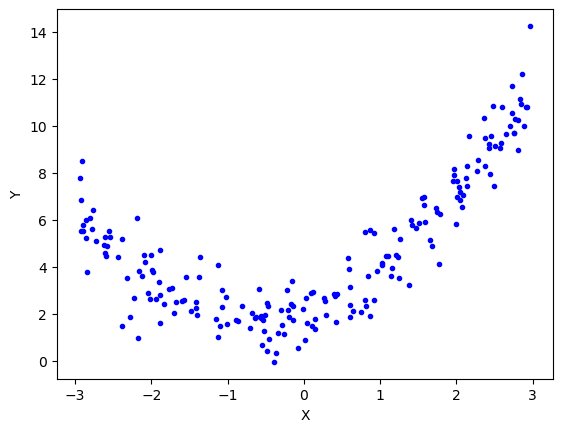

In [3]:
plt.plot(x,y,'b.')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

In [8]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)


In [5]:
lr=LinearRegression()

In [6]:
lr.fit(x_train,y_train)

LinearRegression()

In [9]:
y_pred=lr.predict(x_test)
r2_score(y_test,y_pred)

0.29485384436592477

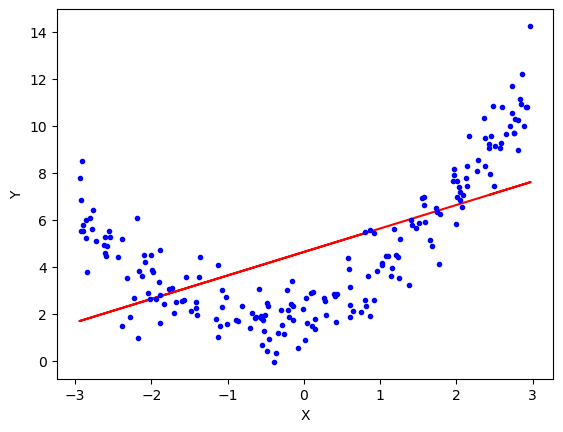

In [10]:
plt.plot(x_train,lr.predict(x_train),color='r')
plt.plot(x,y,'b.')
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [11]:
poly=PolynomialFeatures(degree=2,include_bias=True)
x_train_trans=poly.fit_transform(x_train)
x_test_trans=poly.transform(x_test)


In [12]:
print(x_train[0])
print(x_train_trans[0])

[2.4287684]
[1.         2.4287684  5.89891596]


In [13]:
lr=LinearRegression()
lr.fit(x_train_trans,y_train)

LinearRegression()

In [14]:
y_pred=lr.predict(x_test_trans)

In [16]:
r2_score(y_test,y_pred)

0.9270491573242206

In [17]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.95261516 0.78310383]]
[2.09101471]


In [18]:
x_new=np.linspace(-3,3,200).reshape(200,1)
x_new_poly=poly.transform(x_new)
y_new=lr.predict(x_new_poly)

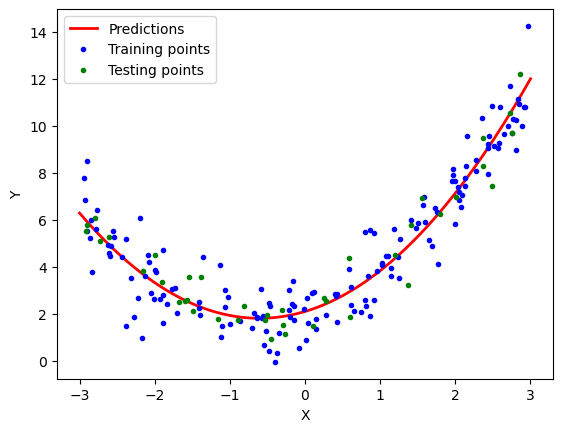

In [19]:
plt.plot(x_new,y_new,'r-',linewidth=2,label='Predictions')
plt.plot(x_train,y_train,'b.',label='Training points')
plt.plot(x_test,y_test,'g.',label='Testing points')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

In [20]:
def polynomial_regression(degree):
    x_new=np.linspace(-3,3,100).reshape(100,1)
    x_new_poly=poly.transform(x_new)
    polybig_features = PolynomialFeatures(degree=degree,include_bias=False)
    std_scaler=StandardScaler()
    lin_reg=LinearRegression()
    polynomial_regression=Pipeline(
        [
            ('poly_feature',polybig_features),
            ('std_scaler',std_scaler),
            ('lin_reg',lin_reg),
        ]
    )
    polynomial_regression.fit(x,y)
    y_newbig=polynomial_regression.predict(x_new)
    plt.plot(x_new,y_newbig,'r',label='Degree' + str(degree),linewidth=2)

    plt.plot(x_train,y_train,'b.',linewidth=3)
    plt.plot(x_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-3, 3, 0, 10])
    plt.show()

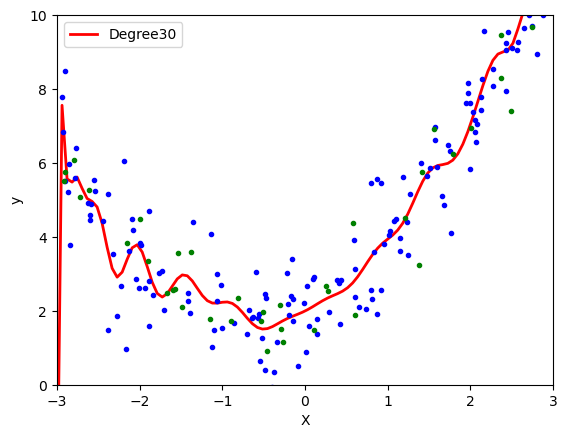

In [21]:
polynomial_regression(30)

In [22]:
poly.powers_

array([[0],
       [1],
       [2]])

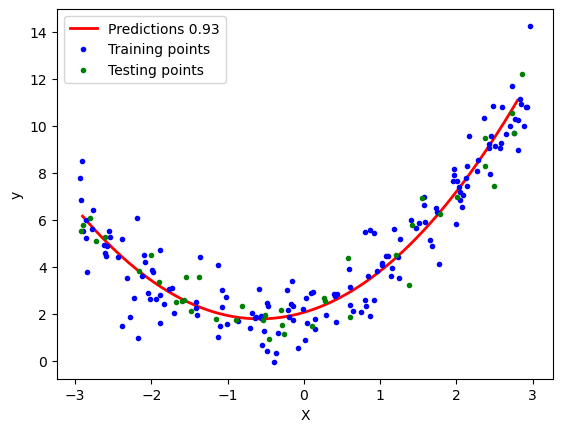

In [24]:
# Applying Gradient Descent
import warnings
warnings.filterwarnings('ignore')
poly = PolynomialFeatures(degree=2)

x_train_trans = poly.fit_transform(x_train)
x_test_trans = poly.transform(x_test)

sgd = SGDRegressor(max_iter=100)
sgd.fit(x_train_trans,y_train)

x_new=np.linspace(-2.9, 2.8, 200).reshape(200, 1)
x_new_poly = poly.transform(x_new)
y_new = sgd.predict(x_new_poly)

y_pred = sgd.predict(x_test_trans)

plt.plot(x_new, y_new, "r-", linewidth=2, label="Predictions " + str(round(r2_score(y_test,y_pred),2)))
plt.plot(x_train, y_train, "b.",label='Training points')
plt.plot(x_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()